In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

from sklearn.datasets import fetch_openml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import seaborn as sns
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler


EPOCHS = 5
LEARNING_RATE = 0.001

DEVICE = "cpu"
if torch.cuda.is_available():
    DEVICE = "cuda"
    print("CUDA device found.", torch.cuda.is_available())
    EPOCHS = 20
elif torch.backends.mps.is_available():
    DEVICE = "mps"
    print ("MPS device found.", torch.backends.mps.is_available())
    EPOCHS = 5
else:
    print("Using CPU device.")
    #BATCH_SIZE = 64

CUDA device found. True


# Recurrent Neural Networks

The RNN type of network and its uses mirror that of a CNN - while the convolutional neural networks excel at capturing spatial relationships in data, RNNs excel at capturing temporal relationships, or things that change over time. This leads to this type of network to be well suited to time series types of problems, and also things like text processing, where the words that occur earlier in a sentence are connected to those that occur later. 

![RNN](images/rnn.png "RNN" )

The unique part of RNNs is that they can loop back, thus allowing the model to discover temporal relationships, or relationships that span over sequential data.

### Data

The starting point of the data is some stock data. We can change the parameters here to different details if we please. 

/tmp/ipykernel_1092/19465381.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_stock_data = yf.download(TICKER, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

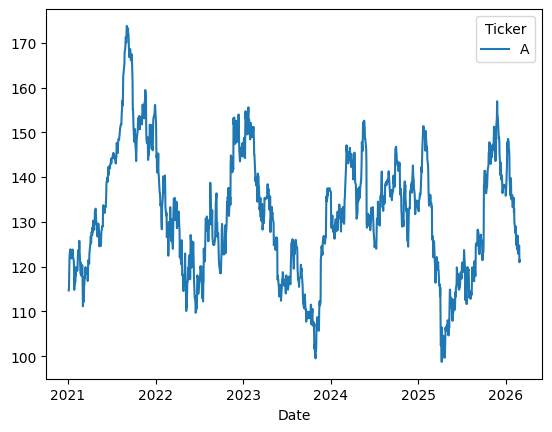

In [ ]:
TICKER = "A"
START_DATE = "2021-01-01"
END_DATE = "2026-03-01"

PRED_LENGTH = 30
LOOKBACK = 90
batch_size = 1

raw_stock_data = yf.download(TICKER, start=START_DATE, end=END_DATE)
sns.lineplot(raw_stock_data["Close"])

#### Generate Data for Predictions

For each point in our data we generate additional data at that point. LSTM models expect data to always be a 3D tensor of the dimensions:
<ul>
<li> [batch_size, timesteps, feature]
</ul>

The outcome of this will be data where each time point is now no longer just 1 value, like a normal time series, but it is a bunch of dates. The X's shape is:
<ul>
<li> (# of rows of data, # of lookback rows, number of features)
<li> I.e. each "row" now has the past 60 values as part of it. 
</ul>

The Y's shape is:
<ul>
<li> (# of rows of data, # of forecasting rows, number of targets)
<li> I.e. each row is a prediction into the future. 
</ul>

Each of the inputs for our data "remembers" the past 60 days into the past! This is what allows these models to do such a good job on sequential data. 

In [ ]:
# Preprocessing - scale, create sequences, split into train/val
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(raw_stock_data[["Close"]].values)

def create_sequences(data, seq_length=30):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

X, y = create_sequences(scaled_data, seq_length=LOOKBACK)
print("Sequence shapes: X {}, y {}".format(X.shape, y.shape))
split_idx = int(len(X) * 0.8)
X_train, y_train = X[:split_idx], y[:split_idx]
X_val, y_val = X[split_idx:], y[split_idx:]

class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]
        #print("StockDataset item shapes: x {}, y {}".format(x.shape, y.shape))
        return x, y
    
train_dataset = StockDataset(X_train, y_train)
val_dataset = StockDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

Sequence shapes: X (1204, 90, 1), y (1204, 1)


In [ ]:
print("Data Shapes: ")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"Train samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")

Data Shapes: 
X_train: (963, 90, 1), y_train: (963, 1)
X_val: (241, 90, 1), y_val: (241, 1)
Train samples: 963, Validation samples: 241


## RNN Models 

We can make the RNN model. Most of the configuration is provided to the RNN layer object directly. We can use it to generate multiple layers of RNNs, and we can also specify the number of hidden units in each layer.

### Go Forward

The output is also a little more complex than a normal feedforward network. The output of the RNN layer is a 3D tensor, not just a value. The code below takes the data from its original shape of (batch_size, timesteps, size) and slices the data to only take the last time step, which is the one we care about for forecasting.

### Create Predictions

To do predictions into the future, we need to use the model in a slightly different way. We only get a prediction for *tomorrow* from the model, how can we know about a month from now? There are a couple of options, we'll use one here and one later. For now, we can capture predictions and add them to the rest of the input data to scroll the data forward in time. This works and is common, but obviously holds up less well the further into the future we want to predict, since we start making predictions based on predictions, which can lead to compounding errors.

In [ ]:
class RNN_Stock_Model(nn.Module):
    def __init__(self, input_size=1, hidden_size=256, num_layers=2):
        super(RNN_Stock_Model, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])  # Use the last output of the sequence
        return out
    
    def createPredictions(self, inital_input, future_steps=30, scaler=None):
        self.eval()

        current_input = inital_input
        if not torch.is_tensor(current_input):
            current_input = torch.tensor(current_input, dtype=torch.float32)
        current_input = current_input.to(DEVICE)
        # Ensure shape (1, seq_len, features). If a batch was passed, take the last sequence only.
        if current_input.dim() == 3:
            if current_input.shape[0] > 1:
                current_input = current_input[-1:].contiguous()
        elif current_input.dim() == 2:
            current_input = current_input.unsqueeze(0)
        elif current_input.dim() == 1:
            current_input = current_input.unsqueeze(0).unsqueeze(-1)

        print("createPred (RNN) seed shape:", current_input.shape)

        predictions = []
        with torch.no_grad():
            for _ in range(future_steps):
                pred = self.forward(current_input)

                if pred.dim() == 1:
                    pred_for_update = pred.unsqueeze(-1)
                else:
                    pred_for_update = pred[:, -1].unsqueeze(-1)

                latest_pred = pred_for_update[-1, 0].item()
                predictions.append(latest_pred)

                next_step = pred_for_update.unsqueeze(1)
                current_input = torch.cat([current_input[:, 1:, :], next_step], dim=1)

        if scaler is not None:
            predictions = scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten().tolist()

        return predictions

## Train Model

The training loop is pretty simple here, with the exception of grabbing the internal predictions for the train and validation data, for plotting. This doesn't need to be done, we just want the visualization. 

In [6]:
def train_model(model, train_loader, val_loader, epochs, criterion, optimizer, device):
    model.to(device)
    train_preds = []
    val_preds = []
    with torch.enable_grad():
        for epoch in range(epochs):
            model.train()
            train_loss = 0.0
            for x_batch, y_batch in train_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                optimizer.zero_grad()
                outputs = model(x_batch)
                #print("Output shape:", outputs.shape, "Output example:", outputs[0].item())
                if epoch == epochs - 1:  # Only store predictions from the last epoch
                    train_preds.append(outputs[0].detach().cpu().numpy())
                #print("Output shape:", outputs.shape, "Target shape:", y_batch.shape)
                loss = criterion(outputs, y_batch)
                loss.backward()
                optimizer.step()
                train_loss += loss.item() 
            avg_train_loss = train_loss / len(train_loader.dataset)
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                    outputs = model(x_batch)
                    loss = criterion(outputs, y_batch)
                    val_loss += loss.item() 
                    if epoch == epochs - 1:  # Only store predictions from the last epoch
                        val_preds.append(outputs[0].detach().cpu().numpy())
            try:            
                avg_val_loss = val_loss / len(val_loader.dataset)
            except:
                avg_val_loss = val_loss
            print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
    print("train preds shape:", np.array(train_preds).shape, "val preds shape:", np.array(val_preds).shape)
    print("Train data shape:", train_loader.dataset.X.shape, "Validation data shape:", val_loader.dataset.X.shape)
    return train_preds, val_preds

In [ ]:
rnn_model = RNN_Stock_Model()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=.0001)

train_rnn_preds, val_rnn_preds = train_model(rnn_model, train_loader, val_loader, EPOCHS, criterion, optimizer, DEVICE)
train_rnn_preds = scaler.inverse_transform(np.array(train_rnn_preds).reshape(-1, 1)).flatten()
train_rnn_preds = train_rnn_preds[:len(train_loader.dataset)]  # Ensure we only take predictions for the training set
val_rnn_preds = scaler.inverse_transform(np.array(val_rnn_preds).reshape(-1, 1)).flatten()
val_rnn_preds = val_rnn_preds[:len(val_loader.dataset)]  # Ensure we only take predictions for the validation set

Epoch 1/20, Train Loss: 0.0065, Val Loss: 0.0283
Epoch 2/20, Train Loss: 0.0059, Val Loss: 0.0264
Epoch 3/20, Train Loss: 0.0056, Val Loss: 0.0229
Epoch 4/20, Train Loss: 0.0047, Val Loss: 0.0188
Epoch 5/20, Train Loss: 0.0036, Val Loss: 0.0153
Epoch 6/20, Train Loss: 0.0026, Val Loss: 0.0376
Epoch 7/20, Train Loss: 0.0021, Val Loss: 0.0210
Epoch 8/20, Train Loss: 0.0017, Val Loss: 0.0101
Epoch 9/20, Train Loss: 0.0014, Val Loss: 0.0208
Epoch 10/20, Train Loss: 0.0015, Val Loss: 0.0211


In [ ]:
new_input = torch.tensor(X_val[-1], dtype=torch.float32).to(DEVICE)
print("Seed for RNN predictions shape:", new_input.shape)
rnn_predictions = rnn_model.createPredictions(new_input, future_steps=PRED_LENGTH, scaler=scaler)

Seed for RNN predictions shape: torch.Size([90, 1])
createPred (RNN) seed shape: torch.Size([1, 90, 1])


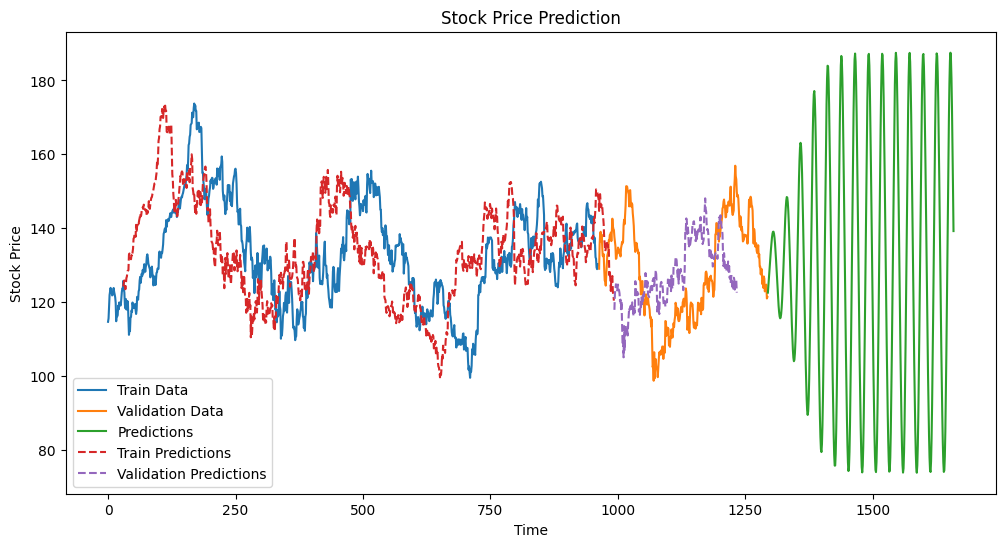

In [ ]:
def plotCombined(train_data, val_data, predictions, train_preds=None, val_preds=None, lb_offset=30):
    plt.figure(figsize=(12, 6))
    train_vals = train_data["Close"].values
    val_vals = val_data["Close"].values
    start_train_idx = max(0, len(train_vals) - len(train_preds)) if train_preds is not None else 0
    start_val_idx = max(0, len(val_vals) - len(val_preds)) if val_preds is not None else 0
    
    plt.plot(range(len(train_vals)), train_vals, label="Train Data")
    plt.plot(range(len(train_vals), len(train_vals) + len(val_vals)), val_vals, label="Validation Data")
    plt.plot(range(len(train_vals) + len(val_vals), len(train_vals) + len(val_vals) + len(predictions)), predictions, label="Predictions")
    if train_preds is not None:
        plt.plot(range(lb_offset, lb_offset + len(train_preds)), train_preds, label="Train Predictions", linestyle='dashed')
    if val_preds is not None:
        plt.plot(range(lb_offset + len(train_vals), lb_offset + len(train_vals) + len(val_preds)), val_preds, label="Validation Predictions", linestyle='dashed')
    plt.legend()
    plt.title("Stock Price Prediction")
    plt.xlabel("Time")
    plt.ylabel("Stock Price")
    plt.show()
plotCombined(raw_stock_data[:split_idx], raw_stock_data[split_idx:], rnn_predictions, train_preds=train_rnn_preds, val_preds=val_rnn_preds, lb_offset=LOOKBACK)

## Long Short Term Memory

Long Short Term Memory (lstm) models are a type of RNN that we can commonly use to make time series predictions. LSTM models function to "remember" certain data and carry that forward, and forget other data. This gives LSTM models the ability to combat the vanishing gradient problem and maintain a "better memory" than a plain implementation of a RNN. LSTM models work by holding a couple of "states", or memory, and control the flow of data through the network and into those states with a set of gates. These LSTM models are near state of the art for sequental problems, surpassed only recently by the Transformer architecture that is in large language models like the GPTs. 

![LSTM](images/lstm.png "LSTM" )

LSTM models have some internal magic that allows them to remember data:
<ul>
<li> Cell state (C) - the "long term memory" of the model.
<li> Hidden state (h) - the "short term memory" of the model.
<li> Forget gate (1) - determines which old data can be dropped.
<li> Input gate (2) - processes new data. 
<li> Output gate (3) - combines the "held" old data with the new data to generate the output. 
</ul>

### LSTM States

The LSTM model holds two types of memory, the long and the short term. Each step of the model's training involves updating both of these states with the new incoming data at that time step. Each state is passed from time step to time step through the model, and the new data is used to update the states by each gate. 

### LSTM Gates

The flow of data into the states is controlled by a series of gates, each using either the tanh or the signmoid activation functions, strategically. Each activation function serves a different purpose here:
<ul>
<li> Sigmoid - acts to scale the importance of weights. 
<li> Tanh - acts to embed the current state in a normalized space. 
</ul>

The gates are:
<ul>
<li> Forget gate - determines which data to forget. The forget gate uses the sigmoid activation function on the current input and the previous hidden state to determine which data to forget. This is passed up to the cell state and multiplied by the current cell state. This acts to raise values that are "important" and lower values that are "unimportant".
<li> Input gate - determines which data to update. This works in conjunction with the "candidate gate", which is the tanh part - techincally it is its own thing, but it is effectively half of the input gate. The input gate generates both a representation and an importance scale of the hidden state and input data with the tanh and sigmoid activation functions. The representation is then multiplied by the importance scale and added to the current cell state. This "adds" the new data to the current cell state, but only the data that is "important" is added.
<li> Output gate - determines which data to output. This takes a representation of the <i>new</i> cell state multiplied by the sigmoid activation function of the hidden state and input data. This takes the importance of the current time step combined with the understanding of the current state. This value is also what is ultimately output from the model, to go into the dense layers for the final prediction.
</ul>

In [ ]:
class LSTM_Stock_Model(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2, pred_length=1):
        super(LSTM_Stock_Model, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, pred_length)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

    def createPredictions(self, inital_input, future_steps=30, scaler=None):
        self.eval()

        current_input = inital_input
        if not torch.is_tensor(current_input):
            current_input = torch.tensor(current_input, dtype=torch.float32)
        current_input = current_input.to(DEVICE)
        # Ensure shape (1, seq_len, features). If a batch was passed, take the last sequence only.
        if current_input.dim() == 3:
            if current_input.shape[0] > 1:
                current_input = current_input[-1:].contiguous()
        elif current_input.dim() == 2:
            current_input = current_input.unsqueeze(0)
        elif current_input.dim() == 1:
            current_input = current_input.unsqueeze(0).unsqueeze(-1)

        print("createPred (LSTM) seed shape:", current_input.shape)

        predictions = []
        with torch.no_grad():
            for _ in range(future_steps):
                pred = self.forward(current_input)

                if pred.dim() == 1:
                    pred_for_update = pred.unsqueeze(-1)
                else:
                    pred_for_update = pred[:, -1].unsqueeze(-1)

                latest_pred = pred_for_update[-1, 0].item()
                predictions.append(latest_pred)

                next_step = pred_for_update.unsqueeze(1)
                current_input = torch.cat([current_input[:, 1:, :], next_step], dim=1)

        if scaler is not None:
            predictions = scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten().tolist()

        return predictions

In [ ]:
lstm_model = LSTM_Stock_Model()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr = .0001)

lstm_train_preds, lstm_val_preds = train_model(lstm_model, train_loader, val_loader, EPOCHS, criterion, optimizer, DEVICE)
lstm_train_preds = scaler.inverse_transform(np.array(lstm_train_preds).reshape(-1, 1)).flatten()
lstm_train_preds = lstm_train_preds[:len(train_loader.dataset)]  # Ensure we only take predictions for the training set
lstm_val_preds = scaler.inverse_transform(np.array(lstm_val_preds).reshape(-1, 1)).flatten()
lstm_val_preds = lstm_val_preds[:len(val_loader.dataset)]  # Ensure we only take predictions for the validation set

Epoch 1/20, Train Loss: 0.0169, Val Loss: 0.0301
Epoch 2/20, Train Loss: 0.0092, Val Loss: 0.0313
Epoch 3/20, Train Loss: 0.0090, Val Loss: 0.0312
Epoch 4/20, Train Loss: 0.0083, Val Loss: 0.0285
Epoch 5/20, Train Loss: 0.0073, Val Loss: 0.0245
Epoch 6/20, Train Loss: 0.0062, Val Loss: 0.0203
Epoch 7/20, Train Loss: 0.0051, Val Loss: 0.0166
Epoch 8/20, Train Loss: 0.0040, Val Loss: 0.0141
Epoch 9/20, Train Loss: 0.0029, Val Loss: 0.0182
Epoch 10/20, Train Loss: 0.0022, Val Loss: 0.0170
Epoch 11/20, Train Loss: 0.0021, Val Loss: 0.0166
Epoch 12/20, Train Loss: 0.0028, Val Loss: 0.0232
Epoch 13/20, Train Loss: 0.0051, Val Loss: 0.0194
Epoch 14/20, Train Loss: 0.0042, Val Loss: 0.0087
Epoch 15/20, Train Loss: 0.0028, Val Loss: 0.0062
Epoch 16/20, Train Loss: 0.0022, Val Loss: 0.0053
Epoch 17/20, Train Loss: 0.0019, Val Loss: 0.0051
Epoch 18/20, Train Loss: 0.0016, Val Loss: 0.0058
Epoch 19/20, Train Loss: 0.0019, Val Loss: 0.0099
Epoch 20/20, Train Loss: 0.0016, Val Loss: 0.0067
train pre

createPred (LSTM) seed shape: torch.Size([1, 90, 1])


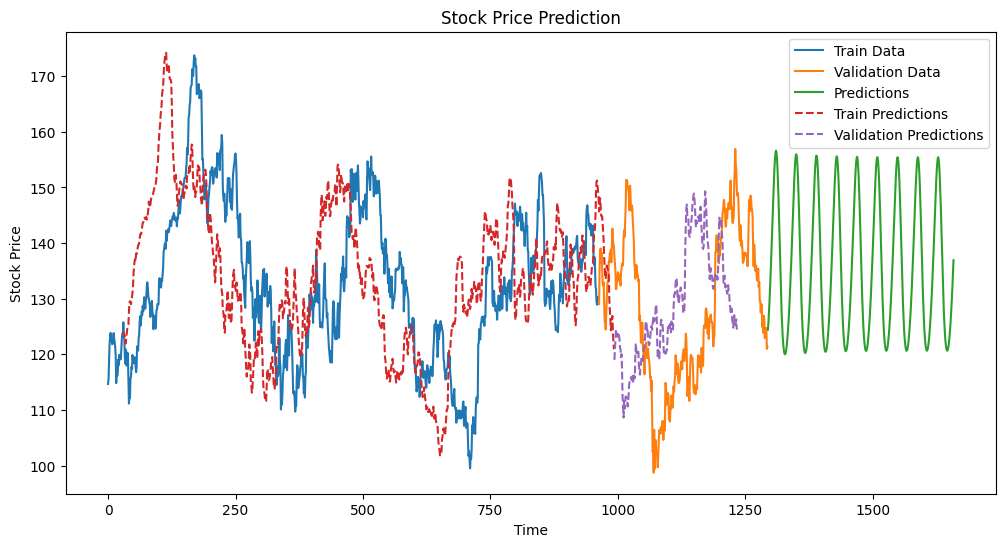

In [ ]:
lstm_predictions = lstm_model.createPredictions(new_input, future_steps=PRED_LENGTH, scaler=scaler)
plotCombined(raw_stock_data[:split_idx], raw_stock_data[split_idx:], lstm_predictions, train_preds=lstm_train_preds, val_preds=lstm_val_preds, lb_offset=LOOKBACK)

## BiDirectional LSTM

### Funky Forecasts

One thing to note here is that if we are doing long term forecasting, the bidirectional model may not be the optimal choice. The performance can be weak (more than normal) for long term recursive forecasting. For something like a piece of text, the bidirectional model is more beneficial. We'll see more on NLP next time. 

In [ ]:
class LSTM_Bidirectional_Stock_Model(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2):
        super(LSTM_Bidirectional_Stock_Model, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, 1)  # Multiply hidden size by 2 for bidirectional

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out
    
    def createPredictions(self, inital_input, future_steps=30, scaler=None):
        self.eval()

        current_input = inital_input
        if not torch.is_tensor(current_input):
            current_input = torch.tensor(current_input, dtype=torch.float32)
        current_input = current_input.to(DEVICE)
        # Ensure shape (1, seq_len, features). If a batch was passed, take the last sequence only.
        if current_input.dim() == 3:
            if current_input.shape[0] > 1:
                current_input = current_input[-1:].contiguous()
        elif current_input.dim() == 2:
            current_input = current_input.unsqueeze(0)
        elif current_input.dim() == 1:
            current_input = current_input.unsqueeze(0).unsqueeze(-1)

        print("createPred (LSTM Bi) seed shape:", current_input.shape)

        predictions = []
        with torch.no_grad():
            for _ in range(future_steps):
                pred = self.forward(current_input)

                if pred.dim() == 1:
                    pred_for_update = pred.unsqueeze(-1)
                else:
                    pred_for_update = pred[:, -1].unsqueeze(-1)

                latest_pred = pred_for_update[-1, 0].item()
                predictions.append(latest_pred)

                next_step = pred_for_update.unsqueeze(1)
                current_input = torch.cat([current_input[:, 1:, :], next_step], dim=1)

        if scaler is not None:
            predictions = scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten().tolist()

        return predictions

In [ ]:
lstm_bi = LSTM_Bidirectional_Stock_Model()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_bi.parameters(), lr = .0001)

train_lstm_bi_preds, val_lstm_bi_preds = train_model(lstm_bi, train_loader, val_loader, EPOCHS, criterion, optimizer, DEVICE)
train_lstm_bi_preds = scaler.inverse_transform(np.array(train_lstm_bi_preds).reshape(-1, 1)).flatten()
train_lstm_bi_preds = train_lstm_bi_preds[:len(train_loader.dataset)]  # Ensure we only take predictions for the training set
val_lstm_bi_preds = scaler.inverse_transform(np.array(val_lstm_bi_preds).reshape(-1, 1)).flatten()
val_lstm_bi_preds = val_lstm_bi_preds[:len(val_loader.dataset)]

Epoch 1/20, Train Loss: 0.0172, Val Loss: 0.0297
Epoch 2/20, Train Loss: 0.0086, Val Loss: 0.0291
Epoch 3/20, Train Loss: 0.0078, Val Loss: 0.0262
Epoch 4/20, Train Loss: 0.0066, Val Loss: 0.0213
Epoch 5/20, Train Loss: 0.0052, Val Loss: 0.0161
Epoch 6/20, Train Loss: 0.0039, Val Loss: 0.0115
Epoch 7/20, Train Loss: 0.0028, Val Loss: 0.0086
Epoch 8/20, Train Loss: 0.0021, Val Loss: 0.0078
Epoch 9/20, Train Loss: 0.0016, Val Loss: 0.0083
Epoch 10/20, Train Loss: 0.0016, Val Loss: 0.0131
Epoch 11/20, Train Loss: 0.0017, Val Loss: 0.0060
Epoch 12/20, Train Loss: 0.0015, Val Loss: 0.0070
Epoch 13/20, Train Loss: 0.0013, Val Loss: 0.0068
Epoch 14/20, Train Loss: 0.0014, Val Loss: 0.0071
Epoch 15/20, Train Loss: 0.0014, Val Loss: 0.0073
Epoch 16/20, Train Loss: 0.0012, Val Loss: 0.0160
Epoch 17/20, Train Loss: 0.0012, Val Loss: 0.0213
Epoch 18/20, Train Loss: 0.0013, Val Loss: 0.0082
Epoch 19/20, Train Loss: 0.0018, Val Loss: 0.0075
Epoch 20/20, Train Loss: 0.0028, Val Loss: 0.0044
train pre

createPred (LSTM Bi) seed shape: torch.Size([1, 90, 1])


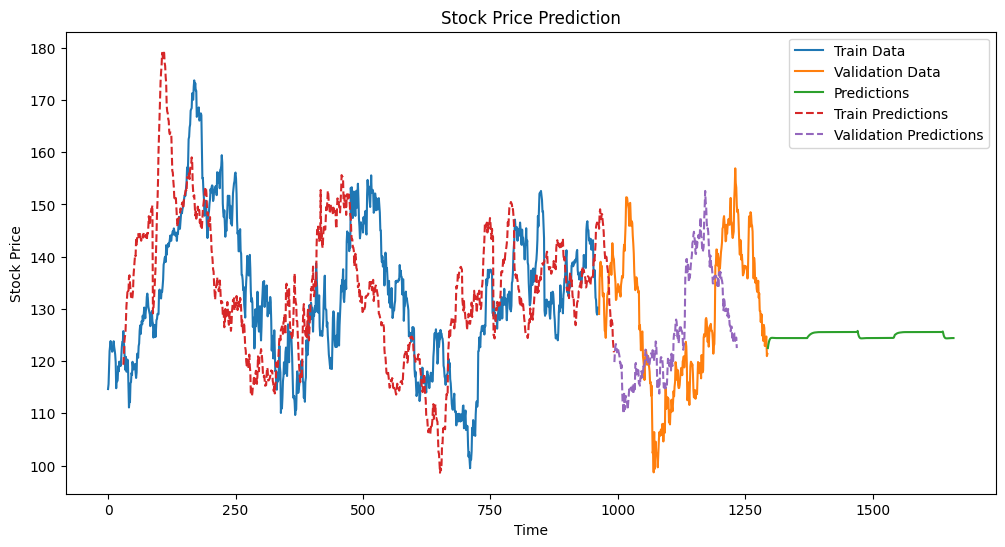

In [ ]:

lstm_bi_predictions = lstm_bi.createPredictions(new_input, future_steps=PRED_LENGTH, scaler=scaler)
plotCombined(raw_stock_data[:split_idx], raw_stock_data[split_idx:], lstm_bi_predictions, train_preds=train_lstm_bi_preds, val_preds=val_lstm_bi_preds, lb_offset=LOOKBACK)

## Exercise

In [ ]:
EX_TICKER = "MSFT"

# Choose a different ticker and try to predict. 

## One-Shot Prediction

In [ ]:
def createSequencesLong(data, seq_length=90, prediction_length=30):
    xs, ys = [], []
    for i in range(len(data) - seq_length - prediction_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length:i+seq_length+prediction_length]
        xs.append(x)
        ys.append(y)
    # resahpe to have 1 feature dimension for the model
    xs = np.array(xs).reshape(-1, seq_length, 1)
    ys = np.array(ys).reshape(-1, prediction_length, 1)
    return np.array(xs), np.array(ys)

one_shot_X, one_shot_y = createSequencesLong(scaled_data, seq_length=90, prediction_length=30)

one_shot_X_train, one_shot_y_train = one_shot_X[:split_idx], one_shot_y[:split_idx]
one_shot_X_val, one_shot_y_val = one_shot_X[split_idx:], one_shot_y[split_idx:]

one_shot_train_dataset = StockDataset(one_shot_X_train, one_shot_y_train)
one_shot_val_dataset = StockDataset(one_shot_X_val, one_shot_y_val)

one_shot_train_loader = DataLoader(one_shot_train_dataset, batch_size=1, shuffle=False)
one_shot_val_loader = DataLoader(one_shot_val_dataset, batch_size=1, shuffle=False)

In [ ]:
one_shot_model = LSTM_Stock_Model(input_size=1, hidden_size=128, num_layers=2, pred_length=30)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(one_shot_model.parameters(), lr = .0001)

one_shot_train_preds, one_shot_val_preds = train_model(one_shot_model, one_shot_train_loader, one_shot_val_loader, EPOCHS, criterion, optimizer, DEVICE)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1, 30, 1])) that is different to the input size (torch.Size([1, 30])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 1/20, Train Loss: 0.0125, Val Loss: 0.0000
Epoch 2/20, Train Loss: 0.0082, Val Loss: 0.0000
Epoch 3/20, Train Loss: 0.0109, Val Loss: 0.0000
Epoch 4/20, Train Loss: 0.0142, Val Loss: 0.0000
Epoch 5/20, Train Loss: 0.0173, Val Loss: 0.0000
Epoch 6/20, Train Loss: 0.0200, Val Loss: 0.0000
Epoch 7/20, Train Loss: 0.0215, Val Loss: 0.0000
Epoch 8/20, Train Loss: 0.0217, Val Loss: 0.0000
Epoch 9/20, Train Loss: 0.0224, Val Loss: 0.0000
Epoch 10/20, Train Loss: 0.0223, Val Loss: 0.0000
Epoch 11/20, Train Loss: 0.0219, Val Loss: 0.0000
Epoch 12/20, Train Loss: 0.0209, Val Loss: 0.0000
Epoch 13/20, Train Loss: 0.0199, Val Loss: 0.0000
Epoch 14/20, Train Loss: 0.0189, Val Loss: 0.0000
Epoch 15/20, Train Loss: 0.0181, Val Loss: 0.0000
Epoch 16/20, Train Loss: 0.0174, Val Loss: 0.0000
Epoch 17/20, Train Loss: 0.0169, Val Loss: 0.0000
Epoch 18/20, Train Loss: 0.0164, Val Loss: 0.0000
Epoch 19/20, Train Loss: 0.0160, Val Loss: 0.0000
Epoch 20/20, Train Loss: 0.0157, Val Loss: 0.0000
train pre

## Datasets with More Features

We can add more features to the model as well. One of the benefits to using a neural network is that adding more features does not require the same work and effort as with traditional time series models. Since we are generating a prediction of N days into the future at any given time, we aren't restricted to the values that "we can know for the future" or offset calculations like we had to do with the ordinary time series models. The increased capacity of neural networks to learn relationships means that our model will accept more data with few changes.

Reconstructing the data to accommodate more features is a bit more cumbersome, we need to create data that is:
<ul>
<li> Y - the next N days of data. 
    <ul>
    <li> Shape - batch size, number of timesteps to predict, 1 value (usually). 
    </ul>
<li> X - the past N days of data, plus the features that we want to use.
    <ul>
    <li> Shape - batch size, number of timesteps to use (M days), number of features.
    </ul>
</ul>

So for any one prediction, the X input is the M day lookback of both the price and all the other features. The Y output is the next N days of price.

#### Nicer Data Prep Function

We can pair this with a more generalized function to prep our data. This one should, assuming I didn't mess it up, allow us to use any number of features and set the time windows to look both forward and backward to whatever we want. The columns' parameter limits the data to those columns, and the y_col specifies which of these is the target. 

In [ ]:
import zipfile
import os
import urllib
import tarfile

def downloadDataset(url: str, destination: str) -> str:
    os.makedirs(destination, exist_ok=True)
    
    # Determine the filename from the URL
    file_name = url.split("/")[-1]
    file_path = os.path.join(destination, file_name)
    
    # Download the file
    if not os.path.exists(file_path):
        print(f"Downloading {url}...")
        urllib.request.urlretrieve(url, file_path)
        print(f"Downloaded to {file_path}")
    else:
        print(f"File already exists at {file_path}, skipping download.")
    
    # Extract if it's a tar/tgz/tar.gz file
    if file_path.endswith((".tgz", ".tar.gz", ".tar")):
        print(f"Extracting {file_path}...")
        with tarfile.open(file_path, "r:*") as tar:
            tar.extractall(path=destination)
        print(f"Extracted to {destination}")
    # Extract if it's a zip file
    elif file_path.endswith(".zip"):
        print(f"Extracting {file_path}...")
        with zipfile.ZipFile(file_path, "r") as zip_ref:
            zip_ref.extractall(destination)
        print(f"Extracted to {destination}")
    else:
        print("No extraction needed.")
    
    # Delete the archive file after extraction
    if file_path.endswith((".tgz", ".tar.gz", ".tar", ".zip")):
        print(f"Removing archive {file_path}...")
        os.remove(file_path)
        print(f"Removed {file_path}")
    # Find the extracted directory
    extracted_dirs = [d for d in os.listdir(destination) if os.path.isdir(os.path.join(destination, d))]
    if extracted_dirs:
        return os.path.join(destination, extracted_dirs[0])
    return file_path

In [ ]:

uri = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"

dataset_path = downloadDataset(uri, "data")
if dataset_path.endswith(".zip"):
    dataset_path = dataset_path[:-4]  # Remove .zip extension to get the CSV path
weather_dataframe = pd.read_csv(dataset_path)
weather_dataframe.head()

Downloaded to data/jena_climate_2009_2016.csv.zip
Extracting data/jena_climate_2009_2016.csv.zip...
Extracted to data
Removing archive data/jena_climate_2009_2016.csv.zip...
Removed data/jena_climate_2009_2016.csv.zip


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [ ]:
PREDICTION_LENGTH = 1
LOOKBACK = 24*7
LEN=6
EXERCISE_EPOCHS = 5
EXERCISE_BATCH = 96

def collapseHours(dataF, date_col="Date Time", spacing=6):
    dataF["to_keep"] = dataF.index % spacing == 0
    tmp_df = dataF[dataF["to_keep"]]
    tmp_df.drop(columns=["to_keep"], inplace=True)
    tmp_df.reset_index(drop=True, inplace=True)
    tmp_df[date_col] = pd.to_datetime(tmp_df[date_col], format="%d.%m.%Y %H:%M:%S")
    del dataF
    return tmp_df

def prepare_weather_data(dataF, cols, y_col="T (degC)", lookback=720, lookahead=1):
    # Select the desired columns
    from sklearn.preprocessing import MinMaxScaler
    data = dataF[cols]

    # Prepare the data for an LSTM model
    x = []
    y = []
    for i in range(lookback, len(data)-lookahead):
        x.append(data.iloc[i-lookback:i].values)
        y.append(data[y_col][i:i+lookahead].values)

    x = np.array(x)  # (n_samples, lookback, n_features)
    y = np.array(y)  # (n_samples, lookahead)

    print("prepare_weather_data shapes before scaling: x", x.shape, "y", y.shape)

    # Scale X per feature
    x_scaler = MinMaxScaler()
    n_samples, seq_len, n_features = x.shape
    x_reshaped = x.reshape(-1, n_features)  # (n_samples * seq_len, n_features)
    x_reshaped_scaled = x_scaler.fit_transform(x_reshaped)
    x = x_reshaped_scaled.reshape(n_samples, seq_len, n_features)

    # Scale y
    y_scaler = MinMaxScaler()
    # If y is 1-D per sample (lookahead==1) reshape to (n_samples, 1) for scaler
    y_shape = y.shape
    if y.ndim == 1:
        y = y.reshape(-1, 1)
    y = y_scaler.fit_transform(y)

    print("prepare_weather_data shapes after scaling: x", x.shape, "y", y.shape)

    return x, y, x_scaler, y_scaler


In [ ]:
class WeatherDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [ ]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter(action='ignore', category=FutureWarning)

    collapsed = collapseHours(weather_dataframe, date_col="Date Time", spacing=LEN)
    collapsed.head()

/tmp/ipykernel_13991/836899254.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_df.drop(columns=["to_keep"], inplace=True)
/tmp/ipykernel_13991/836899254.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_df[date_col] = pd.to_datetime(tmp_df[date_col], format="%d.%m.%Y %H:%M:%S")


In [ ]:
X_one, y_one, x_scaler_one, weather_scaler = prepare_weather_data(collapsed, cols=["T (degC)"], y_col="T (degC)", lookback=LOOKBACK, lookahead=PREDICTION_LENGTH)

train_weather_dataset = WeatherDataset(X_one[:int(0.8*len(X_one))], y_one[:int(0.8*len(y_one))])
val_weather_dataset = WeatherDataset(X_one[int(0.8*len(X_one)):], y_one[int(0.8*len(y_one)):])

train_weather_loader = DataLoader(train_weather_dataset, batch_size=EXERCISE_BATCH, shuffle=False)
val_weather_loader = DataLoader(val_weather_dataset, batch_size=EXERCISE_BATCH, shuffle=False)

prepare_weather_data shapes before scaling: x (69923, 168, 1) y (69923, 1)
prepare_weather_data shapes after scaling: x (69923, 168, 1) y (69923, 1)


In [ ]:
class WeatherModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2):
        super(WeatherModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])  # Use the last output of the sequence
        return out
    
    def createPredictions(self, inital_input, future_steps=30, scaler=None):
        self.eval()

        current_input = inital_input
        if not torch.is_tensor(current_input):
            current_input = torch.tensor(current_input, dtype=torch.float32)
        current_input = current_input.to(DEVICE)
        # Ensure shape (1, seq_len, features). If a batch was passed, take the last sequence only.
        if current_input.dim() == 3:
            if current_input.shape[0] > 1:
                current_input = current_input[-1:].contiguous()
        elif current_input.dim() == 2:
            current_input = current_input.unsqueeze(0)
        elif current_input.dim() == 1:
            current_input = current_input.unsqueeze(0).unsqueeze(-1)

        print("createPred (WeatherModel) seed shape:", current_input.shape)

        predictions = []
        with torch.no_grad():
            for _ in range(future_steps):
                pred = self.forward(current_input)

                if pred.dim() == 1:
                    pred_for_update = pred.unsqueeze(-1)
                else:
                    pred_for_update = pred[:, -1].unsqueeze(-1)

                latest_pred = pred_for_update[-1, 0].item()
                predictions.append(latest_pred)

                next_step = pred_for_update.unsqueeze(1)
                current_input = torch.cat([current_input[:, 1:, :], next_step], dim=1)

        if scaler is not None:
            predictions = scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten().tolist()

        return predictions

def plotWeatherPredictions( train_dataloader, val_dataloader=None, train_preds=None, val_preds=None, predictions=None):
    pass

In [ ]:
single_feature_weather_model = WeatherModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(single_feature_weather_model.parameters(), lr=.0001)

train_single_preds, val_single_preds = train_model(single_feature_weather_model, train_weather_loader, val_weather_loader, EXERCISE_EPOCHS, criterion, optimizer, DEVICE)
train_single_preds = weather_scaler.inverse_transform(np.array(train_single_preds).reshape(-1, 1)).flatten()
train_single_preds = train_single_preds[:len(train_weather_loader.dataset)]  # Ensure we only take predictions for the training set
val_single_preds = weather_scaler.inverse_transform(np.array(val_single_preds).reshape(-1, 1)).flatten()
val_single_preds = val_single_preds[:len(val_weather_loader.dataset)]  # Ensure we only take predictions for the validation set

new_input_weather = torch.tensor(X_one[-1], dtype=torch.float32).to(DEVICE)
print("Seed for weather predictions shape:", new_input_weather.shape)
single_feature_predictions = single_feature_weather_model.createPredictions(new_input_weather, future_steps=PRED_LENGTH, scaler=weather_scaler)
single_feature_predictions = weather_scaler.inverse_transform(np.array(single_feature_predictions).reshape(-1, 1)).flatten()

Epoch 1/5, Train Loss: 0.0003, Val Loss: 0.0002
Epoch 2/5, Train Loss: 0.0002, Val Loss: 0.0002
Epoch 3/5, Train Loss: 0.0001, Val Loss: 0.0002
Epoch 4/5, Train Loss: 0.0001, Val Loss: 0.0001
Epoch 5/5, Train Loss: 0.0001, Val Loss: 0.0001
train preds shape: (583, 1) val preds shape: (146, 1)
Train data shape: torch.Size([55938, 168, 1]) Validation data shape: torch.Size([13985, 168, 1])
Seed for weather predictions shape: torch.Size([168, 1])
createPred (WeatherModel) seed shape: torch.Size([1, 168, 1])


### Multiple Features

In [ ]:
weather_columns = collapsed.columns
weather_columns = weather_columns[weather_columns != "Date Time"]
print("Columns Used:", weather_columns)
X_weather, y_weather, x_scaler_mult, scaler_mult = prepare_weather_data(collapsed, cols=weather_columns, y_col="T (degC)", lookback=LOOKBACK, lookahead=PREDICTION_LENGTH)

print(X_weather.shape, y_weather.shape)

Columns Used: Index(['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)',
       'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)',
       'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)',
       'wd (deg)'],
      dtype='object')
prepare_weather_data shapes before scaling: x (69923, 168, 14) y (69923, 1)
prepare_weather_data shapes after scaling: x (69923, 168, 14) y (69923, 1)
(69923, 168, 14) (69923, 1)


In [ ]:
multi_feature_weather_dataset = WeatherDataset(X_weather[:int(0.8*len(X_weather))], y_weather[:int(0.8*len(y_weather))])
val_multi_feature_weather_dataset = WeatherDataset(X_weather[int(0.8*len(X_weather)):], y_weather[int(0.8*len(y_weather)):])

multi_feature_weather_loader = DataLoader(multi_feature_weather_dataset, batch_size=EXERCISE_BATCH, shuffle=False)
val_multi_feature_weather_loader = DataLoader(val_multi_feature_weather_dataset, batch_size=EXERCISE_BATCH, shuffle=False)

In [ ]:
class MultiFeatureWeather(nn.Module):
    def __init__(self, input_size=13, hidden_size=128, num_layers=2):
        super(MultiFeatureWeather, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])  # Use the last output of the sequence
        return out

In [ ]:
#
multi_feature_model = MultiFeatureWeather(input_size=X_weather.shape[2])
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(multi_feature_model.parameters(), lr=.0001)

train_multi_preds, val_multi_preds = train_model(multi_feature_model, multi_feature_weather_loader, val_multi_feature_weather_loader, EXERCISE_EPOCHS, criterion, optimizer, DEVICE)
train_multi_preds = scaler_mult.inverse_transform(np.array(train_multi_preds).reshape(-1, 1)).flatten()
train_multi_preds = train_multi_preds[:len(multi_feature_weather_loader.dataset)]  # Ensure we only take predictions for the training set
val_multi_preds = scaler_mult.inverse_transform(np.array(val_multi_preds).reshape(-1, 1)).flatten()
val_multi_preds = val_multi_preds[:len(val_multi_feature_weather_loader.dataset)]  # Ensure we only take predictions for the validation set


Epoch 1/5, Train Loss: 0.0002, Val Loss: 0.0001
Epoch 2/5, Train Loss: 0.0001, Val Loss: 0.0000
Epoch 3/5, Train Loss: 0.0000, Val Loss: 0.0000
Epoch 4/5, Train Loss: 0.0000, Val Loss: 0.0000
Epoch 5/5, Train Loss: 0.0000, Val Loss: 0.0000
train preds shape: (583, 1) val preds shape: (146, 1)
Train data shape: torch.Size([55938, 168, 14]) Validation data shape: torch.Size([13985, 168, 14])


## Future Projection

This model can predict into the future, but what values do we feed it to make those predictions? For the single value model, we can use the predictions as the features for future predictions. 

For a multi-feature model, we need to figure out something if we want to project farther into the future. We don't have all of these features for the things we're predicting, so if we want this model to be useful, we need to perform some kind of hack. There are several options here, we could:
<ul>
<li> Generate predictions for the features. </li>
<li> Create longer intial predictions, so one 'round' predicts values going into the future. </li>
<li> Use the last known values for the features, and just update the target variable with the predictions. </li>
</ul>

None of these is perfect, and the relative performance of these options will likely depend on the data and the features.

In [ ]:
class WeatherLongPrediction(nn.Module):
    def __init__(self, input_size=13, hidden_size=128, num_layers=2, pred_length=30):
        super(WeatherLongPrediction, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, pred_length)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])  # Use the last output of the sequence
        return out

    def genPred(self, inital_input, scaler=None):
        self.eval()

        current_input = inital_input
        if not torch.is_tensor(current_input):
            current_input = torch.tensor(current_input, dtype=torch.float32)
        current_input = current_input.to(DEVICE)

        if current_input.dim() == 1:
            current_input = current_input.unsqueeze(0).unsqueeze(-1)
        elif current_input.dim() == 2:
            current_input = current_input.unsqueeze(0)

        print("genPred (WeatherLongPrediction) seed shape:", current_input.shape)

        with torch.no_grad():
            pred = self.forward(current_input)

        pred = pred.cpu().numpy().flatten()

        if scaler is not None:
            n_in = getattr(scaler, 'n_features_in_', None)
            if n_in == pred.shape[0]:
                pred = scaler.inverse_transform(pred.reshape(1, -1)).flatten()
            elif n_in == 1:
                pred = scaler.inverse_transform(pred.reshape(-1, 1)).flatten()
            else:
                try:
                    pred = scaler.inverse_transform(pred.reshape(1, -1)).flatten()
                except Exception:
                    pred = scaler.inverse_transform(pred.reshape(-1, 1)).flatten()

        return pred

In [ ]:
X_long, y_long, x_scaler_long, scaler_long = prepare_weather_data(collapsed, cols=weather_columns, y_col="T (degC)", lookback=144, lookahead=30)
long_weather_dataset = WeatherDataset(X_long[:int(0.8*len(X_long))], y_long[:int(0.8*len(y_long))])
val_long_weather_dataset = WeatherDataset(X_long[int(0.8*len(X_long)):], y_long[int(0.8*len(y_long)):])

long_weather_loader = DataLoader(long_weather_dataset, batch_size=EXERCISE_BATCH, shuffle=False)
val_long_weather_loader = DataLoader(val_long_weather_dataset, batch_size=EXERCISE_BATCH, shuffle=False)

prepare_weather_data shapes before scaling: x (69918, 144, 14) y (69918, 30)
prepare_weather_data shapes after scaling: x (69918, 144, 14) y (69918, 30)


In [ ]:
long_model = WeatherLongPrediction(input_size=X_long.shape[2], pred_length=30)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(long_model.parameters(), lr=.0001)

train_long_preds, val_long_preds = train_model(long_model, long_weather_loader, val_long_weather_loader, EXERCISE_EPOCHS, criterion, optimizer, DEVICE)
train_long_preds = scaler_long.inverse_transform(np.array(train_long_preds).reshape(-1, 30)).flatten()
train_long_preds = train_long_preds[:len(long_weather_loader.dataset)]  # Ensure we only take predictions for the training set
val_long_preds = scaler_long.inverse_transform(np.array(val_long_preds).reshape(-1, 30)).flatten()
val_long_preds = val_long_preds[:len(val_long_weather_loader.dataset)]  # Ensure we only take predictions for the validation

Epoch 1/5, Train Loss: 0.0004, Val Loss: 0.0002
Epoch 2/5, Train Loss: 0.0002, Val Loss: 0.0002
Epoch 3/5, Train Loss: 0.0002, Val Loss: 0.0002
Epoch 4/5, Train Loss: 0.0001, Val Loss: 0.0001
Epoch 5/5, Train Loss: 0.0001, Val Loss: 0.0001
train preds shape: (583, 30) val preds shape: (146, 30)
Train data shape: torch.Size([55934, 144, 14]) Validation data shape: torch.Size([13984, 144, 14])


In [ ]:
new_input_long = torch.tensor(X_long[-1], dtype=torch.float32).to(DEVICE)
long_model_predictions = long_model.genPred(new_input_long, scaler=scaler_long)
print("Long model predictions for the next 30 hours:", long_model_predictions)

genPred (WeatherLongPrediction) seed shape: torch.Size([1, 144, 14])
Long model predictions for the next 30 hours: [3.958745  4.1851535 4.219191  4.3249125 4.387899  4.1455016 4.155368
 4.363232  4.419663  4.150641  4.015001  3.976008  3.8815327 4.1131425
 4.2315836 4.1435275 3.9394124 4.0298157 4.0609493 4.3929996 4.235347
 4.1755977 4.404829  4.037965  3.9774394 4.13989   4.112594  4.0865016
 4.2616687 4.083996 ]


### LSTM - Tuning Performance

Like any other neural network model, we can change some things to try to improve the performance of our model. Like any other network, the true test of our model will come down to experimentation and testing. 

#### Unit Size and Layers

The "number of neurons" argument in creating an LSTM layer is the number of units in the layer. This parameter defines the size of the hidden state vector that is passed between the layers and combines with the size of the input to define the rest of the sizes of the weight matricies. The units is not related to the time steps, it is better though of as roughly the size of the data that we are processing at each time step. This works like the number of neurons in a normal dense layer, the larger the value, the higher the capacity of that layer to learn. 

Adding layers to the LSTM model is the other general strategy to creating a more powerful model - the more layers we add, the more complex the model can be, and the more it can learn. The basic structure of an LSTM model is similar to what we saw in a CNN, we have the "specialized stuff" in the first layers, either LSTM or CNN, then we add on some amount to dense layers to generate a final prediction. Models that have multiple LSTM layers are often called "stacked LSTM" models.

As with dense models, we need to decide how large to make our model in capacity, and how to balance that betweeen the two ways to add capacity - "width", or the number of units in each layer, and "depth", or the number of layers. This is something that ultimately needs to be tested to be firmly determined, but we can use some rules of thumb to give us good starting points:
<ul>
<li> If we have a "simple" pattern, like the examples that were easy to predict with moving average based strategies, one LSTM layer should be enough, likely with fewer than 50 units, maybe far fewer. 
<li> For more complex patterns:
    <ul>
    <li> A good starting point is to use about 50 units the first LSTM layer. If the problem appears complex, and maybe one other layer with a similar number of units.
    <li> If the patterns in the data appear to be largely defined by <b>interactions between multiple input features</b> or by <b>pattern blocks</b>, such as those identified by technical stock trading above, then we should try more units. 
    <li> If the patterns in the data appear to be <b>highly abstract</b>, such as parts of speech/language being components of full sentences, then we should try more layers. This lines up with very deep models being good at things like language translation, the structure and capacity of the model is well suited to the problem of language, with very abstract relationships. This is conceptually similar to how deeper CNN models are able to transform images through multiple layers and extract useful features on which to base a prediction - the deep LSTM models are able to transform temporal data through multiple layers and extract useful features.
    </ul>
</ul>

The relative balance between the two ways to add capacity can't be too far out of balance, which is a guideline without specifics; we are less likely to see good results with an LSTM layer of 3,000 units and one layer, or 2 units and 75 layers. In general, things that are based on unstructured data such as NLP based applications will tend to be better suited with a deep model, things like a sales forecast can likely be well served by a more shallow model. The training times for very deep models with large timesteps can get very large, as can the memory requirements. There is a rule of thumb that we can use for an estimate for a total number of units, but it is, at best, a very rough guideline:
<ul>
<li> Units = samples in training data / ((# input neurons + # output neurons) * alpha)
<li> Where alpha is a constant normally between 2 and 10, with 5 being a good starting point.
</ul>

So an algorithmic approach to deciding on a rough starting size for a model would be to calculate the total neurons above, using an alpha that mirrors the complexity, then divide that by one layer for a simple problem, two or more for a complex problem. The farther we get from a simple time-series problem, the less likely this rule of thumb will be precise. 

#### Dropouts in LSTM

Dropout layers are commonly used in LSTM models as a way to prevent overfitting. There are two basic ways that dropout layers can be used in an LSTM model:
<ul>
<li> Dropout between LSTM layers. 
<li> Dropout after LSTM layers, before the output layer. 
</ul>

Of the two, placing the dropout between LSTM layers will generally give more variance in the impact of the layer - potentially in both directions. There are also many other varieties of dropout strategies being researched, all seeking to be situationally smarter variations of the standard dropout layer we've applied here. While dropout layers are extremely common to see in LSTM models, they are not certain to improve model performance and their usefulness needs to be tested to be truly evaluated.

#### Keras Tuner

We can use the Keras Tuner to do some hyperparameter tuning for the best configuration. The same principles apply as with any other model, we need to define a search space, and then run the search. One thing that we can do to make our search space smaller and allow more time for productive search, we can likely create smaller models that visually seem to "follow the trend" if we plot the training data - take that model that looks decent, and search +/- some units, +/- some layers, and try some variations such as dropouts or an additional dense layer. 

## Exercise - Try It

Start from the raw weather data, and make predictions. 